# AI Data Analysis Assistant
### Track A – Explorer | AI Data Analysis Challenge

This notebook follows the 5 steps of the challenge, one step per section:

1. Load Dataset
2. Analyze the Dataset
3. Answer Natural Language Questions
4. Generate a Chart
5. Explain the Result

## Step 0: Import libraries

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


## Step 1: Load Dataset
Read the CSV file and look at its basic information.

In [8]:
df = pd.read_csv("train.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", list(df.columns))
df.head()

Rows: 9800
Columns: 18
Column names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
# Data types and missing values
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


## Step 2: Analyze the Dataset
Calculate a few simple, useful statistics using pandas.

In [10]:
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
max_sales = df["Sales"].max()
min_sales = df["Sales"].min()
total_orders = df["Order ID"].nunique()
total_products = df["Product Name"].nunique()

print("Total sales:", round(total_sales, 2))
print("Average sales:", round(average_sales, 2))
print("Max sales:", round(max_sales, 2))
print("Min sales:", round(min_sales, 2))
print("Total orders:", total_orders)
print("Total unique products:", total_products)

Total sales: 2261536.78
Average sales: 230.77
Max sales: 22638.48
Min sales: 0.44
Total orders: 4922
Total unique products: 1849


## Step 3: Answer Natural Language Questions

We use simple `if` / `elif` checks: look for keywords in the question,
then run the matching pandas calculation.

In [11]:
def answer_question(df, question):
    q = question.lower()

    if "product" in q and ("highest" in q or "top" in q or "most" in q):
        grouped = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)
        return f"'{grouped.index[0]}' has the highest sales, with a total of {grouped.iloc[0]:,.2f}."

    if "average" in q and "sales" in q:
        return f"The average sales value is {df['Sales'].mean():,.2f}."

    if "city" in q and "order" in q:
        grouped = df.groupby("City")["Order ID"].nunique().sort_values(ascending=False)
        return f"'{grouped.index[0]}' has the maximum number of orders: {grouped.iloc[0]}."

    if "category" in q and ("frequent" in q or "most" in q or "common" in q):
        counts = df["Category"].value_counts()
        return f"'{counts.index[0]}' is the most frequent category, appearing {counts.iloc[0]} times."

    if "total" in q and "sales" in q:
        return f"The total sales amount is {df['Sales'].sum():,.2f}."

    if "region" in q and ("highest" in q or "top" in q or "most" in q):
        grouped = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
        return f"'{grouped.index[0]}' region has the highest sales, with a total of {grouped.iloc[0]:,.2f}."

    return "I can answer questions about highest sales product, average sales, city with maximum orders, most frequent category, total sales, and region with highest sales."


print("Function ready.")

Function ready.


In [12]:
# --- The judges' 3 fixed questions go here ---
questions = [
    "Which product has the highest sales?",
    "Which city has the maximum orders?",
    "Which category is most frequent?",
]

for q in questions:
    print("Q:", q)
    print("A:", answer_question(df, q))
    print()

Q: Which product has the highest sales?
A: 'Canon imageCLASS 2200 Advanced Copier' has the highest sales, with a total of 61,599.82.

Q: Which city has the maximum orders?
A: 'New York City' has the maximum number of orders: 439.

Q: Which category is most frequent?
A: 'Office Supplies' is the most frequent category, appearing 5909 times.



## Step 4: Generate a Chart
A bar chart showing total sales for each category.

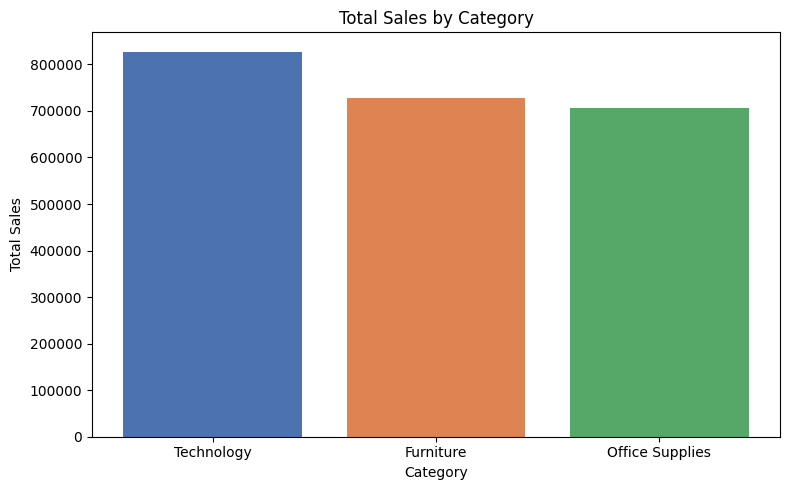

In [13]:
grouped = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(grouped.index, grouped.values, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()

os.makedirs("charts", exist_ok=True)
plt.savefig("charts/bar_chart.png")
plt.show()

## Step 5: Explain the Result

We write a simple sentence describing the chart. If an `ANTHROPIC_API_KEY`
environment variable is set, we ask Claude to make the sentence friendlier.
Otherwise, we just use our own simple sentence — the notebook works either way.

In [14]:
top_category = grouped.index[0]
top_value = grouped.iloc[0]
percentage = (top_value / grouped.sum()) * 100

explanation = (
    f"The {top_category} category contributes the highest sales, "
    f"accounting for approximately {percentage:.1f}% of total sales."
)

api_key = os.environ.get("ANTHROPIC_API_KEY")
if api_key:
    try:
        import anthropic
        client = anthropic.Anthropic(api_key=api_key)
        response = client.messages.create(
            model="claude-sonnet-4-5",
            max_tokens=100,
            messages=[{"role": "user", "content": f"Rewrite this in one simple, friendly sentence: {explanation}"}],
        )
        explanation = response.content[0].text.strip()
    except Exception:
        pass  # if the API call fails, we just keep our simple sentence

print(explanation)

The Technology category contributes the highest sales, accounting for approximately 36.6% of total sales.


## Summary

- **Step 1:** Loaded `dataset.csv` and checked its shape, columns, and missing values.
- **Step 2:** Calculated total, average, max, and min sales, plus order and product counts.
- **Step 3:** Answered natural language questions using simple keyword matching.
- **Step 4:** Generated a bar chart of total sales by category.
- **Step 5:** Explained the chart in one simple sentence.

The same logic is used in `backend/analysis.py`, `backend/visualization.py`
(FastAPI backend) and `streamlit_app.py` (Streamlit frontend).